In [1]:
import numpy as np
import itertools
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_OriginalOperator
import matplotlib.pyplot as plt

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
Lambda = 5.4e15 / mpl * (Pi / 10)**(-1) * M * phic**0.5
nWaterfall = 1
mu1 = Pi**2 * M**(-2) * phic**(-1)
mu2 = 10
psirc = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5

def infPotFunc(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * ((1 - (psir / M)**2)**2 + 2 * (phi * psir / phic / M)**2 + (phi - phic) / mu1 - ((phi - phic) / mu2)**2))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (4 * phi * (psir / phic / M)**2 + 1 / mu1 - 2 * (phi - phic) / mu2**2))
    
def infPotDerivFunc_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 * psir / M**2 * (1 - (psir / M)**2) + 4 * psir * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    psir = Phi[1]
    return float(Lambda**4 * (4 * (psir / phic / M)**2 - 2 / mu2**2))

def infPotDeriv2Func_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psir / M / M)**2 + 4 * (phi / phic / M)**2))


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psir]
infPotentialDeriv2Funcs = [infPotDeriv2Func_phi, infPotDeriv2Func_psir]

nGrid = 64
phimin = 0.999995 * phic
phimax = phic + 20 / mu1
psimax = 1e-4 * M
psimin = 0.1 * psirc
customGrid_phi = np.linspace(phimin, phimax, nGrid)
customGrid_psir = np.exp(np.linspace(np.log(psimin), np.log(psimax), nGrid))

In [3]:
phitest = phimin
psirtest = customGrid_psir[1]
Phitest = np.array([phitest, psirtest])
print(infPotFunc(Phitest))
print(infPotDerivFunc_phi(Phitest))
print((infPotFunc(Phitest + np.array([phitest * 0.01, 0])) - infPotFunc(Phitest - np.array([phitest * 0.01, 0]))) / (phitest * 0.02))
print(infPotDerivFunc_psir(Phitest))
print((infPotFunc(Phitest + np.array([0, psirtest * 0.001])) - infPotFunc(Phitest - np.array([0, psirtest * 0.001]))) / (psirtest * 0.002))
print(infPotDeriv2Func_phi(Phitest))
print((infPotDerivFunc_phi(Phitest + np.array([phitest * 0.01, 0])) - infPotDerivFunc_phi(Phitest - np.array([phitest * 0.01, 0]))) / (phitest * 0.02))
print(infPotDeriv2Func_psir(Phitest))
print((infPotDerivFunc_psir(Phitest + np.array([0, psirtest * 0.01])) - infPotDerivFunc_psir(Phitest - np.array([0, psirtest * 0.01]))) / (psirtest * 0.02))

2.309130063155654e-32
2.8539290807947685e-42
2.7174487551341525e-42
-4.9993230818822826e-48
0.0
-4.618260126311308e-34
-4.618260126311298e-34
-1.3770148664584386e-30
-1.3770148662232464e-30


In [4]:
fpFinDiff_NeuNeu = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, psimin],
    ["Neumann0", "Neumann0"],
    ["Neumann0", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir]
)

# ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psir_woEnd = customGrid_psir[1:-1]
vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psir_woEnd)), False)
for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
            maskMat[i1, i2] = True
            fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuNeu, eigVecs_NeuNeu = np.linalg.eig(fpFinDiff_NeuNeu)
eigVecsSort_NeuNeu = eigVecs_NeuNeu.T[np.argsort(eigVals_NeuNeu)]
eigValsSort_NeuNeu = np.sort(eigVals_NeuNeu)

In [10]:
fpFinDiff_NeuNeu

array([[ 9.88260781e+01, -9.88260781e+01,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.71830194e+01,  4.58029829e+01, -9.29860022e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  6.18039379e+01,  2.12283365e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         2.18852253e-14,  8.04431880e-01,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -8.13152488e-01,  2.18841788e-14,  8.13152488e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00, -4.19011398e-19,  2.18836937e-14]])

In [5]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, psimin],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir]
)

for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


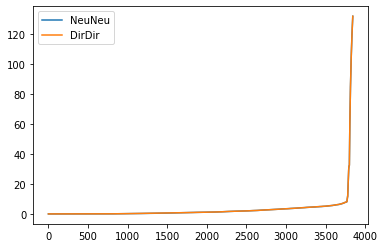

In [6]:
ax = plt.gca()
plt.plot(eigValsSort_NeuNeu, label = "NeuNeu")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

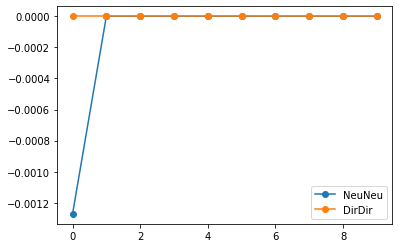

In [7]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_NeuNeu[:10], marker='o', label = "NeuNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [8]:
np.set_printoptions(formatter={'complexfloat': '{:.30f}'.format})
print(eigValsSort_NeuNeu[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[-0.001271430706414490531194760869+0.000000000000000000000000000000j
 -0.000000000007275957614183425903-71884.317848458231310360133647918701j
 -0.000000000007275957614183425903+71884.317848458231310360133647918701j
 -0.000000000005456968210637569427-66314.345693273542565293610095977783j
 -0.000000000005456968210637569427-43873.757203805005701724439859390259j
 -0.000000000005456968210637569427+43873.757203805005701724439859390259j
 -0.000000000005456968210637569427+66314.345693273542565293610095977783j
 -0.000000000003637978807091712952-63882.775019305605383124202489852905j
 -0.000000000003637978807091712952+63882.775019305605383124202489852905j
 -0.000000000003183231456205248833-74869.887576265857205726206302642822j]
[-0.000000000014551915228366851807-150302.526699412206653505563735961914j
 -0.000000000014551915228366851807-146133.068250557116698473691940307617j
 -0.000000000014551915228366851807-141588.488573492941213771700859069824j
 -0.000000000014551915228366851807+141588.488573492

In [12]:
fpFinDiff_DirAll = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, psimin],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psir]
)

for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if maskMat[i1, i2]: fpFinDiff_DirAll[i1, i2] = 0

eigVals_DirAll, eigVecs_DirAll = np.linalg.eig(fpFinDiff_DirAll)
eigVecsSort_DirAll = eigVecs_DirAll.T[np.argsort(eigVals_DirAll)]
eigValsSort_DirAll = np.sort(eigVals_DirAll)


c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


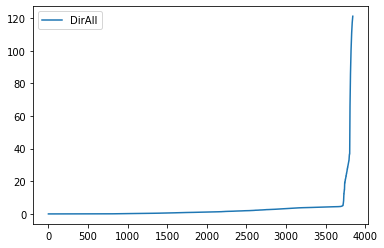

In [13]:
ax = plt.gca()
plt.plot(eigValsSort_DirAll, label = "DirAll")
plt.legend()
plt.show()

In [15]:
np.set_printoptions(formatter={'complexfloat': '{:.30f}'.format})
print(eigValsSort_DirAll[0:10])
np.set_printoptions()

[-0.000000000014551915228366851807-146133.068250557291321456432342529297j
 -0.000000000014551915228366851807+146133.068250557291321456432342529297j
 -0.000000000005172751116333529353-169518.242516306112520396709442138672j
 -0.000000000005172751116333529353+169518.242516306112520396709442138672j
 -0.000000000003637978807091712952-160458.121977965376572683453559875488j
 -0.000000000003637978807091712952+160458.121977965376572683453559875488j
 -0.000000000002046363078989088535-33099.018877272967074532061815261841j
 -0.000000000002046363078989088535+33099.018877272967074532061815261841j
 -0.000000000001250555214937776327-36388.012529070394521113485097885132j
 -0.000000000001250555214937776327+36388.012529070394521113485097885132j]


In [16]:
fpFinDiff_DirAll

array([[ 9.88260781e+01, -1.33231449e+02,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.71830194e+01,  4.58029829e+01, -9.29860022e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  6.18039379e+01,  2.12283365e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         2.18852253e-14,  8.04431880e-01,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -8.13152488e-01,  2.18841788e-14,  8.13152488e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00, -1.39836143e+00,  2.18836937e-14]])